# Group By

In [1]:
import pandas as pd

# Create sample data
data = {'Category': ['A', 'B', 'A', 'B', 'A', 'C'],
        'Subcategory': ['a', 'a', 'a', 'a', 'b', 'a'],
        'Value1' : [1, 2, 3, 4, 5, 6],
        'Value2': [10, 20, 30, 40, 50, 60]}

df = pd.DataFrame(data)

# Group by 'Category' column
grouped = df.groupby('Category')

# Iterate over grouped
for name, group in grouped:
    print("-"*40)
    print("Sub-DataFrame Name:", name)
    print(group)

----------------------------------------
Sub-DataFrame Name: A
  Category Subcategory  Value1  Value2
0        A           a       1      10
2        A           a       3      30
4        A           b       5      50
----------------------------------------
Sub-DataFrame Name: B
  Category Subcategory  Value1  Value2
1        B           a       2      20
3        B           a       4      40
----------------------------------------
Sub-DataFrame Name: C
  Category Subcategory  Value1  Value2
5        C           a       6      60


In [2]:
# Apply count function to grouped data
summary = grouped["Subcategory"].value_counts().unstack(fill_value=0)
print(summary)

Subcategory  a  b
Category         
A            2  1
B            2  0
C            1  0


In [3]:
import pandas as pd

# Sample data
x = pd.Series([1, 2, 3, 12, 14, 17, 22, 28])
y = pd.Series([10, 20, 30, 40, 50, 60, 70, 80])  # some numeric values to group

# Define bins from 0 to 30 with step 10
bins = pd.interval_range(start=0, end=30, freq=10, closed='left')

# Bin the x values
x_binned = pd.cut(x, bins)

# Group y by the binned x and take the mean
group_means = y.groupby(x_binned).mean()

print(group_means)

[0, 10)     20.0
[10, 20)    50.0
[20, 30)    75.0
dtype: float64


C:\Users\march\AppData\Local\Temp\ipykernel_24832\3153856175.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = y.groupby(x_binned).mean()


### 🧠 What's happening:

Let’s look at `x_binned`:

| x value | Bin       |
|---------|-----------|
| 1       | [0, 10)   |
| 2       | [0, 10)   |
| 3       | [0, 10)   |
| 12      | [10, 20)  |
| 14      | [10, 20)  |
| 17      | [10, 20)  |
| 22      | [20, 30)  |
| 28      | [20, 30)  |

Then for grouping:

- `[0, 10)` → y values: [10, 20, 30] → mean = 20.0  
- `[10, 20)` → y values: [40, 50, 60] → mean = 50.0  
- `[20, 30)` → y values: [70, 80] → mean = 75.0  

---

### ✅ Output:

```
[0, 10)     20.0  
[10, 20)    50.0  
[20, 30)    75.0  
dtype: float64
```

This shows how **multiple data points in the same bin** are aggregated cleanly by `groupby`.

Let me know if you’d like a version that adds bin centers, or fills in missing bins with `0` or `NaN`.

## Poission Regression Example

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Sample data generation
np.random.seed(42)
X = np.random.uniform(0, 10, 100000)
Y = np.random.poisson(lam=np.exp(0.3 * X - 1))

df = pd.DataFrame({'X': X, 'Y': Y})

# Add intercept
df['intercept'] = 1

# Fit Poisson regression model
model = sm.GLM(df['Y'], df[['intercept', 'X']], family=sm.families.Poisson()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99998
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5917e+05
Date:                Wed, 02 Apr 2025   Deviance:                   1.0861e+05
Time:                        17:24:59   Pearson chi2:                 1.00e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.7585
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.9904      0.007   -150.000      0.0

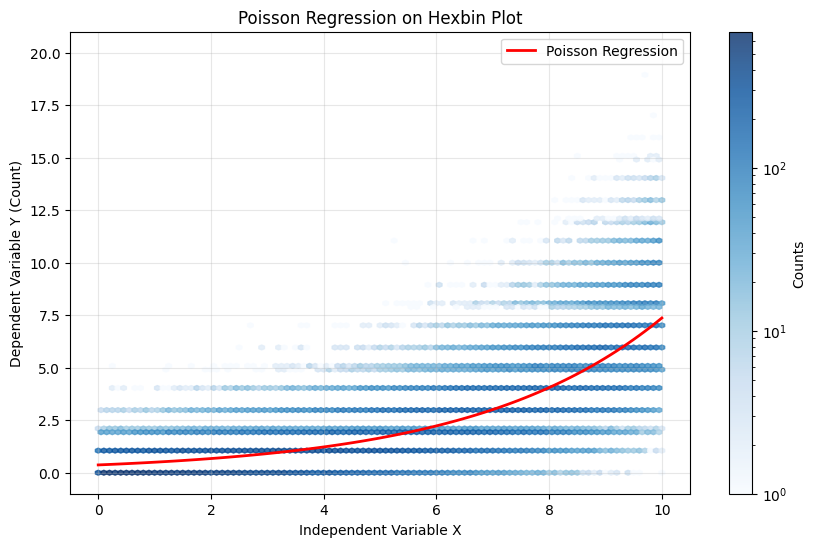

In [5]:
X_pred = np.linspace(df['X'].min(), df['X'].max(), 100)
X_pred_df = pd.DataFrame({'intercept': 1, 'X': X_pred})
Y_pred = model.predict(X_pred_df)

plt.figure(figsize=(10, 6))

# Hexbin plot for original data
hb = plt.hexbin(df['X'], df['Y'], gridsize=100, cmap='Blues', mincnt=1, alpha=0.8, bins='log')
plt.colorbar(hb, label='Counts')

# Overlay regression line
plt.plot(X_pred, Y_pred, color='red', linewidth=2, label='Poisson Regression')

# Labels and title
plt.xlabel('Independent Variable X')
plt.ylabel('Dependent Variable Y (Count)')
plt.title('Poisson Regression on Hexbin Plot')
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()


## Negative Binomial Regression Example

In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Example data
np.random.seed(0)
X = np.random.exponential(10, 100000)
mu = np.exp(0.0080 * X + 2.4627)  # mean of the count
size = 1/0.3366  # dispersion parameter
Y = np.random.negative_binomial(n=size, p=size / (size + mu))

df = pd.DataFrame({'X': X, 'Y': Y})

# Add constant (intercept)
df['intercept'] = 1

# Fit model
model_nb = sm.NegativeBinomial(df['Y'], df[['intercept', 'X']]).fit()

print(model_nb.summary())

Optimization terminated successfully.
         Current function value: 3.399573
         Iterations: 11
         Function evaluations: 15
         Gradient evaluations: 15
                     NegativeBinomial Regression Results                      
Dep. Variable:                      Y   No. Observations:               100000
Model:               NegativeBinomial   Df Residuals:                    99998
Method:                           MLE   Df Model:                            1
Date:                Wed, 02 Apr 2025   Pseudo R-squ.:                0.002435
Time:                        17:25:04   Log-Likelihood:            -3.3996e+05
converged:                       True   LL-Null:                   -3.4079e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.4655      0.003    85

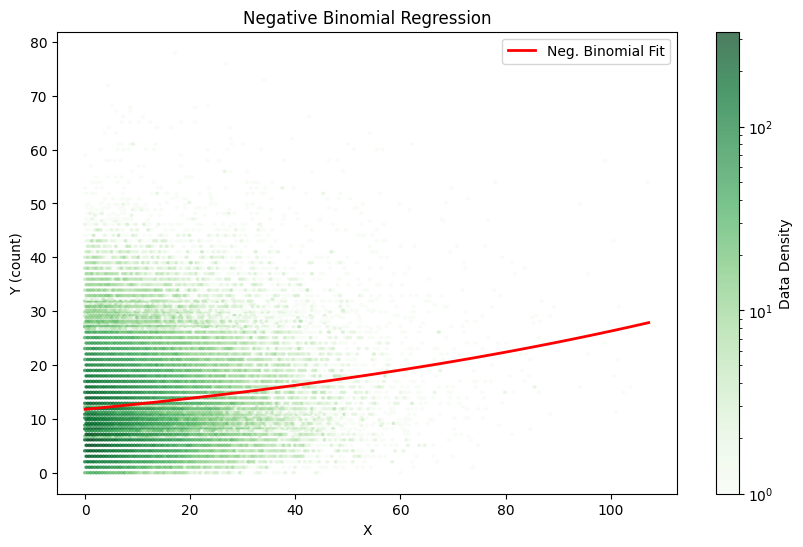

In [7]:
# Predict over a range of X values
X_pred = np.linspace(df['X'].min(), df['X'].max(), 100)
X_pred_df = pd.DataFrame({'X': X_pred})
X_pred_df['intercept'] = 1

# Predict using model
Y_pred = model_nb.predict(X_pred_df[['intercept', 'X']])

# Plot data + fitted line
plt.figure(figsize=(10,6))
plt.hexbin(df['X'], df['Y'], gridsize=200, cmap='Greens', mincnt=1, alpha=0.7, bins='log')
plt.plot(X_pred, Y_pred, color='red', linewidth=2, label='Neg. Binomial Fit')
plt.xlabel('X')
plt.ylabel('Y (count)')
plt.title('Negative Binomial Regression')
plt.colorbar(label='Data Density')
plt.legend()
plt.show()

In [8]:
type(Y_pred)

pandas.core.series.Series